# Лабораторная работа E11 — Управление последовательностями

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biomenace/digital-signal-processing/blob/main/notebooks/e11.ipynb)

Ноутбук-спутник к интерактивной работе: **[открыть саму лабораторную](https://biomenace.github.io/digital-signal-processing/labs/e11.html)**.

**Что разбираем.** Каналов на культе мало — обычно два: агонист и антагонист.
А команд протезу нужно много: закрыть, открыть, повернуть кисть, сменить
режим. Выход тот же, что у мыши с двумя кнопками: значение несёт не сам факт
сокращения, а его **рисунок во времени**.

Три «жеста», из которых собирается всё остальное:

* **тап** — короткое сокращение, короче порога $T_{hold}$;
* **удержание** — сокращение длиннее $T_{hold}$;
* **co-contraction** — оба канала напряжены одновременно.

Несколько тапов подряд, разделённых паузой меньше $T_{gap}$, склеиваются в
серию — ровно как двойной щелчок мышью. Дальше поток жестов подаётся в
**конечный автомат**: одно и то же сокращение означает разное в зависимости
от текущего состояния протеза.

In [1]:
# ЯЧЕЙКА 1 · Установка и импорты.
# Запусти один раз в начале работы и больше сюда не возвращайся.
# В Google Colab почти всё уже стоит, поэтому обычно ничего не скачивается.

import importlib.util
import subprocess
import sys


def ensure(packages):
    """Ставит только те пакеты, которых нет. packages: [(модуль, имя-для-pip)]."""
    missing = [pip for mod, pip in packages if not importlib.util.find_spec(mod)]
    if missing:
        print("Ставлю:", ", ".join(missing))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing],
                       check=True)
    print("Готово. Python", sys.version.split()[0])


ensure([("numpy", "numpy"), ("scipy", "scipy"), ("matplotlib", "matplotlib")])

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib.rcParams.update({
    "figure.figsize": (11, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.linewidth": 0.4,
    "axes.titlesize": 12,
    "font.size": 11,
})

Готово. Python 3.10.12


## Ячейка 2 · Вспомогательные функции

Свёртка сокращений в события, склейка тапов в серии, сам автомат и рисование
ленты. Запусти один раз и дальше просто вызывай.

In [2]:
def detect_events(contractions, t_hold, cc_overlap):
    """Свернуть список сокращений (канал, начало_мс, длительность_мс) в события.

    Сокращение длиннее t_hold — удержание, короче — тап. Два сокращения на
    разных каналах, перекрывающиеся минимум на долю cc_overlap от меньшей
    длительности, сливаются в одно событие co-contraction.
    """
    segments = sorted(
        [{"ch": ch, "t0": float(t0), "t1": float(t0 + dur)}
         for ch, t0, dur in contractions],
        key=lambda s: s["t0"],
    )
    used = [False] * len(segments)
    events = []
    for i, s in enumerate(segments):
        if used[i]:
            continue
        partner = None
        for j, other in enumerate(segments):
            if j == i or used[j] or other["ch"] == s["ch"]:
                continue
            overlap = min(s["t1"], other["t1"]) - max(s["t0"], other["t0"])
            shorter = min(s["t1"] - s["t0"], other["t1"] - other["t0"])
            if overlap > 0 and shorter > 0 and overlap / shorter >= cc_overlap:
                partner = j
                break
        if partner is not None:
            used[i] = used[partner] = True
            events.append({"kind": "cc", "ch": "A+B",
                           "t0": min(s["t0"], segments[partner]["t0"]),
                           "t1": max(s["t1"], segments[partner]["t1"])})
            continue
        used[i] = True
        kind = "hold" if s["t1"] - s["t0"] >= t_hold else "tap"
        events.append({"kind": kind, "ch": s["ch"], "t0": s["t0"], "t1": s["t1"]})
    events.sort(key=lambda e: e["t0"])
    return events


def group_taps(events, t_gap):
    """Склеить подряд идущие тапы в серии: пауза меньше t_gap — та же серия."""
    out = []
    i = 0
    while i < len(events):
        if events[i]["kind"] != "tap":
            out.append({**events[i], "n": 1})
            i += 1
            continue
        j = i
        while (j + 1 < len(events) and events[j + 1]["kind"] == "tap"
               and events[j + 1]["t0"] - events[j]["t1"] <= t_gap):
            j += 1
        out.append({"kind": "tap", "n": j - i + 1,
                    "t0": events[i]["t0"], "t1": events[j]["t1"]})
        i = j + 1
    return out


def run_state_machine(gestures, transitions, state="rest"):
    """Прогнать поток жестов через автомат, вернуть список команд с таймингами."""
    log = []
    for gesture in gestures:
        key = (state, gesture["kind"])
        if key not in transitions:
            continue
        new_state, command = transitions[key]
        if gesture["kind"] == "tap" and gesture["n"] > 1:
            command = "%d тапа подряд — «команда %d»" % (gesture["n"], gesture["n"])
            new_state = state          # серия тапов не меняет режим, это «набор номера»
        log.append({"t": gesture["t0"], "from": state, "to": new_state,
                    "kind": gesture["kind"], "n": gesture["n"], "cmd": command})
        state = new_state
    return log


def plot_timeline(contractions, events, log):
    """Лента активности каналов сверху, распознанные команды снизу."""
    fig, (ax_top, ax_bottom) = plt.subplots(
        2, 1, figsize=(12, 5.6), gridspec_kw={"height_ratios": [2, 1]})
    t_max = max(t0 + dur for _, t0, dur in contractions) + 500
    lanes = {"A": 1.0, "B": 0.0}
    cc_spans = [(e["t0"], e["t1"]) for e in events if e["kind"] == "cc"]

    for ch, t0, dur in contractions:
        in_cc = any(t0 >= s0 - 1 and t0 + dur <= s1 + 1 for s0, s1 in cc_spans)
        color = "seagreen" if in_cc else ("steelblue" if ch == "A" else "mediumpurple")
        ax_top.barh(lanes[ch], dur, left=t0, height=0.55, color=color, alpha=0.85)
    labels = {"tap": "тап", "hold": "удержание", "cc": "co-contraction"}
    for event in events:
        ax_top.text(event["t0"], 1.62, labels[event["kind"]], fontsize=8, color="0.35")
    ax_top.set(yticks=[0.0, 1.0], xlim=(-100, t_max), ylim=(-0.6, 2.0),
               title="Лента активности каналов")
    ax_top.set_yticklabels(["канал B", "канал A"])

    ax_bottom.axhline(0.4, color="0.85", lw=1)
    for entry in log:
        ax_bottom.axvline(entry["t"], color="darkorange", lw=1, alpha=0.6)
        ax_bottom.text(entry["t"], 0.45, entry["cmd"], rotation=25, fontsize=8,
                       ha="left", va="bottom")
    ax_bottom.set(xlim=(-100, t_max), ylim=(0, 1.6), yticks=[],
                  xlabel="время, мс", title="Распознанные команды")
    ax_bottom.grid(False)
    fig.tight_layout()
    plt.show()

## Ячейка 3 · Автомат и сценарий сокращений

Таблица переходов — то же, что нарисовано диаграммой в браузерной версии.
Ключ это пара (состояние, жест), значение — новое состояние и команда.

In [3]:
TRANSITIONS = {
    ("rest", "tap"):   ("rest",  "клик (команды нет)"),
    ("rest", "hold"):  ("grip",  "ЗАХВАТ — закрыть кисть"),
    ("rest", "cc"):    ("mode2", "смена режима — 2"),
    ("grip", "tap"):   ("rest",  "ОТПУСТИТЬ — открыть кисть"),
    ("grip", "hold"):  ("grip",  "сжать сильнее"),
    ("grip", "cc"):    ("mode2", "смена режима — 2"),
    ("mode2", "tap"):  ("rot",   "ПОВЕРНУТЬ кисть"),
    ("mode2", "hold"): ("mode2", "стоп, пауза"),
    ("mode2", "cc"):   ("rest",  "смена режима — 1"),
    ("rot", "tap"):    ("mode2", "поворот назад"),
    ("rot", "hold"):   ("rot",   "зафиксировать угол"),
    ("rot", "cc"):     ("rest",  "смена режима — 1"),
}
STATE_NAMES = {"rest": "Покой", "grip": "Хват", "mode2": "Режим 2", "rot": "Поворот"}

# Сценарий: (канал, начало в мс, длительность в мс). Меняй его — это и есть
# «набор команды сокращениями» из виджета.
CONTRACTIONS = [
    ("A", 200, 120),     # тап 1
    ("A", 480, 120),     # тап 2, пауза 160 мс — та же серия
    ("A", 1600, 800),    # удержание
    ("A", 3000, 110),    # тап
    ("A", 3260, 110),    # тап
    ("A", 3520, 110),    # тап — серия из трёх
    ("A", 5000, 300),    # co-contraction: A и B перекрываются
    ("B", 5050, 300),
]

print("Сокращений в сценарии: %d" % len(CONTRACTIONS))
for ch, t0, dur in CONTRACTIONS:
    print("   канал %s: с %5d мс, длительность %3d мс" % (ch, t0, dur))

Сокращений в сценарии: 8
   канал A: с   200 мс, длительность 120 мс
   канал A: с   480 мс, длительность 120 мс
   канал A: с  1600 мс, длительность 800 мс
   канал A: с  3000 мс, длительность 110 мс
   канал A: с  3260 мс, длительность 110 мс
   канал A: с  3520 мс, длительность 110 мс
   канал A: с  5000 мс, длительность 300 мс
   канал B: с  5050 мс, длительность 300 мс


## Ячейка 4 · Из сокращений — в жесты

Три порога ниже определяют всё поведение системы. Меняй их и смотри, как одна
и та же запись начинает читаться по-другому.

In [4]:
T_HOLD = 600.0      # сокращение не короче этого — удержание, иначе тап, мс
T_GAP = 450.0       # пауза не больше этой — тапы в одной серии, мс
CC_OVERLAP = 0.4    # доля перекрытия каналов, чтобы засчитать co-contraction

events = detect_events(CONTRACTIONS, T_HOLD, CC_OVERLAP)
gestures = group_taps(events, T_GAP)

print("Пороги: T_hold=%.0f мс, T_gap=%.0f мс, перекрытие=%.2f\n"
      % (T_HOLD, T_GAP, CC_OVERLAP))
print("Найденные жесты:")
for event in events:
    print("   t=%6.0f мс  %-5s  (%s, %.0f мс)"
          % (event["t0"], event["kind"], event["ch"], event["t1"] - event["t0"]))

print("\nПосле склейки серий: %d элементов" % len(gestures))
for gesture in gestures:
    suffix = " ×%d" % gesture["n"] if gesture["n"] > 1 else ""
    print("   t=%6.0f мс  %s%s" % (gesture["t0"], gesture["kind"], suffix))

Пороги: T_hold=600 мс, T_gap=450 мс, перекрытие=0.40

Найденные жесты:
   t=   200 мс  tap    (A, 120 мс)
   t=   480 мс  tap    (A, 120 мс)
   t=  1600 мс  hold   (A, 800 мс)
   t=  3000 мс  tap    (A, 110 мс)
   t=  3260 мс  tap    (A, 110 мс)
   t=  3520 мс  tap    (A, 110 мс)
   t=  5000 мс  cc     (A+B, 350 мс)

После склейки серий: 4 элементов
   t=   200 мс  tap ×2
   t=  1600 мс  hold
   t=  3000 мс  tap ×3
   t=  5000 мс  cc


## Ячейка 5 · Автомат выдаёт команды

Одинаковые жесты дают разные команды: тап в покое ничего не делает, а тап в
состоянии «Хват» разжимает кисть.

Распознано команд: 4

   t=   200 мс  [Покой    → Покой   ]  2 тапа подряд — «команда 2»
   t=  1600 мс  [Покой    → Хват    ]  ЗАХВАТ — закрыть кисть
   t=  3000 мс  [Хват     → Хват    ]  3 тапа подряд — «команда 3»
   t=  5000 мс  [Хват     → Режим 2 ]  смена режима — 2


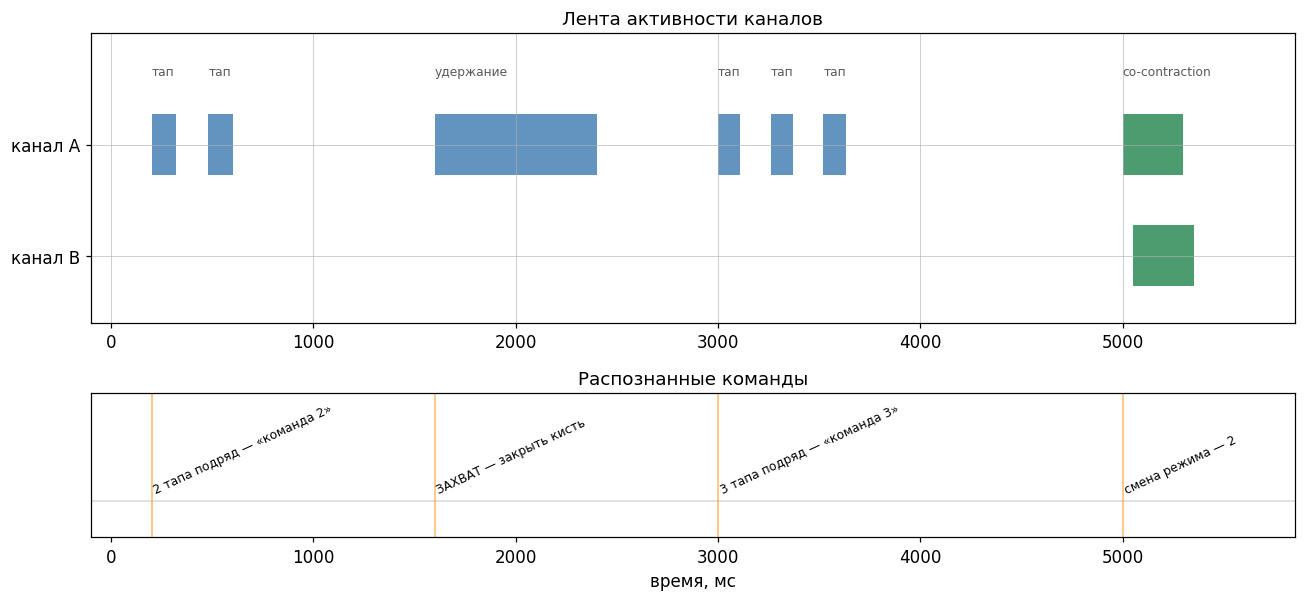

In [5]:
log = run_state_machine(gestures, TRANSITIONS)

print("Распознано команд: %d\n" % len(log))
for entry in log:
    print("   t=%6.0f мс  [%-8s → %-8s]  %s"
          % (entry["t"], STATE_NAMES[entry["from"]], STATE_NAMES[entry["to"]], entry["cmd"]))

plot_timeline(CONTRACTIONS, events, log)

## Ячейка 6 · Что делают пороги

Порог $T_{hold}$ решает, где кончается тап и начинается удержание. Порог
$T_{gap}$ решает, где кончается одна серия и начинается следующая. Сдвинь их —
и та же самая запись мышцы даст другую последовательность команд.

In [6]:
print("%10s %10s %8s %8s   %s" % ("T_hold, мс", "T_gap, мс", "жестов", "команд", "первая команда"))
for t_hold in (300.0, 600.0, 900.0):
    for t_gap in (200.0, 450.0):
        ev = detect_events(CONTRACTIONS, t_hold, CC_OVERLAP)
        gs = group_taps(ev, t_gap)
        lg = run_state_machine(gs, TRANSITIONS)
        first = lg[0]["cmd"] if lg else "—"
        print("%10.0f %10.0f %8d %8d   %s" % (t_hold, t_gap, len(gs), len(lg), first))

T_hold, мс  T_gap, мс   жестов   команд   первая команда
       300        200        4        4   2 тапа подряд — «команда 2»
       300        450        4        4   2 тапа подряд — «команда 2»
       600        200        4        4   2 тапа подряд — «команда 2»
       600        450        4        4   2 тапа подряд — «команда 2»
       900        200        4        4   2 тапа подряд — «команда 2»
       900        450        4        4   2 тапа подряд — «команда 2»


При `T_hold = 300` мс удержание на 800 мс остаётся удержанием, но при
`T_hold = 900` мс оно превращается в тап — и вместо захвата протез не делает
ничего. Слишком строгий порог утомляет человека, слишком мягкий даёт ложные
срабатывания.

## Ячейка 7 · Своя последовательность

Опиши нужную цепочку команд и проверь, что автомат читает её именно так.

t=   200 мс  [Покой    → Хват    ]  ЗАХВАТ — закрыть кисть
t=  1500 мс  [Хват     → Покой   ]  ОТПУСТИТЬ — открыть кисть
t=  2600 мс  [Покой    → Режим 2 ]  смена режима — 2
t=  3600 мс  [Режим 2  → Поворот ]  ПОВЕРНУТЬ кисть


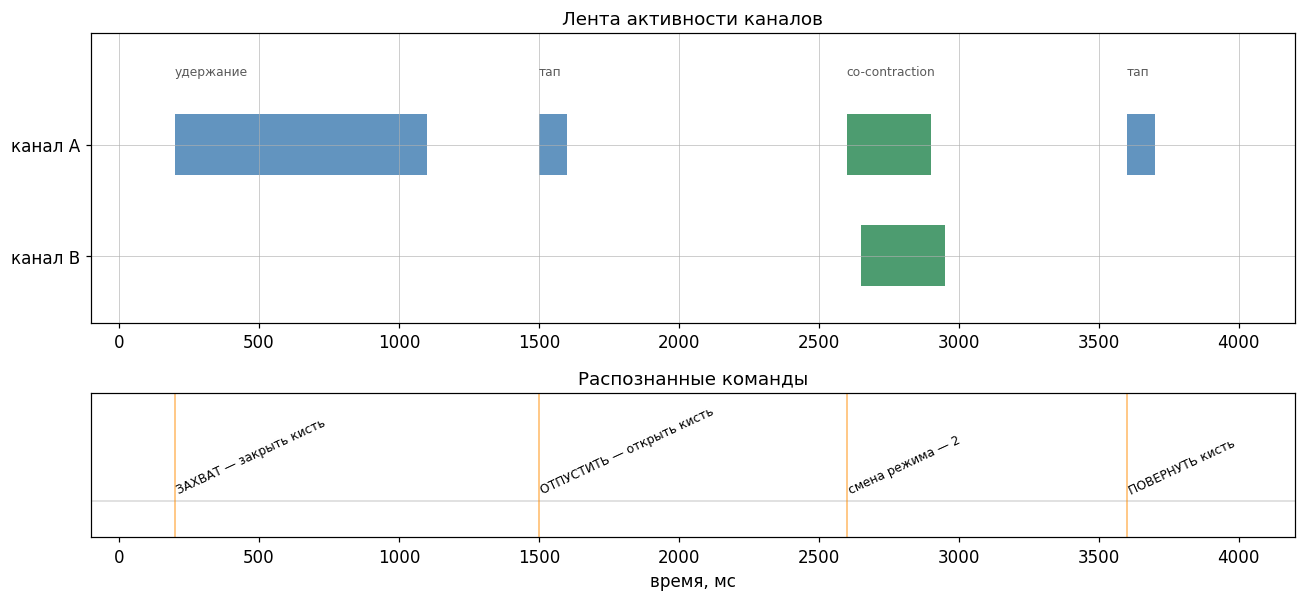

In [7]:
MY_SCENARIO = [
    ("A", 200, 900),     # удержание — захват
    ("A", 1500, 100),    # тап — отпустить
    ("A", 2600, 300),    # co-contraction — смена режима
    ("B", 2650, 300),
    ("A", 3600, 100),    # тап в режиме 2 — поворот
]

my_events = detect_events(MY_SCENARIO, T_HOLD, CC_OVERLAP)
my_log = run_state_machine(group_taps(my_events, T_GAP), TRANSITIONS)
for entry in my_log:
    print("t=%6.0f мс  [%-8s → %-8s]  %s"
          % (entry["t"], STATE_NAMES[entry["from"]], STATE_NAMES[entry["to"]], entry["cmd"]))

plot_timeline(MY_SCENARIO, my_events, my_log)

## Задания

1. Для своих порогов из таблицы вариантов запиши, сколько жестов и сколько
   команд получается из демо-сценария.
2. Придумай сценарий сокращений, который проводит протез по цепочке
   «покой → хват → покой → режим 2 → поворот». Проверь его в ячейке 7.
3. Найди значение `T_gap`, при котором три тапа перестают склеиваться в одну
   серию. Объясни, чем это плохо для человека, который набирает команду.